In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import pickle
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

In [4]:
df1 = pd.read_csv('/content/drive/MyDrive/SeventhSemMl/transaction_dataset.csv')
df2 = pd.read_csv('/content/drive/MyDrive/SeventhSemMl/nepali_transactions_advanced.csv')

print(f'DF1 shape: {df1.shape}')
print(f'DF2 shape (original): {df2.shape}')

# --- FIX: Upsample df2 so Nepali entries are statistically visible ---
# With 5M rows in df1 and ~500 rows in df2, df2 is only 0.01% of data.
# The model essentially never learns from it. Target: df2 = ~2% of final dataset.
TARGET_RATIO = 0.02
needed_rows  = int(len(df1) * TARGET_RATIO)
repeats      = max(1, needed_rows // len(df2))

print(f'\nUpsampling df2 {repeats}x to reach ~{needed_rows:,} Nepali rows')
df2_upsampled = pd.concat([df2] * repeats, ignore_index=True)
print(f'DF2 shape (upsampled): {df2_upsampled.shape}')

# Merge and shuffle
df = pd.concat([df1, df2_upsampled], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Merged shape: {df.shape}')
print(f'\nFirst few rows:')
df.head()

DF1 shape: (4501043, 4)
DF2 shape (original): (1000, 2)

Upsampling df2 90x to reach ~90,020 Nepali rows
DF2 shape (upsampled): (90000, 2)
Merged shape: (4591043, 5)

First few rows:


,transaction_description,category,country,currency,description
0,Trader Joe's - AUSTRALIA,Food & Dining,AUSTRALIA,AUD,NaN
1,Southwest Airlines,Transportation,CANADA,CAD,NaN
2,Senate - INDIA,Government & Legal,INDIA,INR,NaN
3,Passport (Wire),Government & Legal,INDIA,INR,NaN
4,Subway Online - Weekday,Food & Dining,USA,USD,NaN


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4591043 entries, 0 to 4591042
Data columns (total 5 columns):
 #   Column                   Dtype 
---  ------                   ----- 
 0   transaction_description  object
 1   category                 object
 2   country                  object
 3   currency                 object
 4   description              object
dtypes: object(5)
memory usage: 175.1+ MB
None

Missing Values:
transaction_description      90000
category                         0
country                      90000
currency                     90000
description                4501043
dtype: int64

Number of unique categories: 10

Category Distribution:
category
Utilities & Services          460842
Government & Legal            460108
Financial Services            459959
Income                        459545
Charity & Donations           459133
Shopping & Retail             458941
Healthcare & Medical          458857
Entertainment & Recreation    458495
T

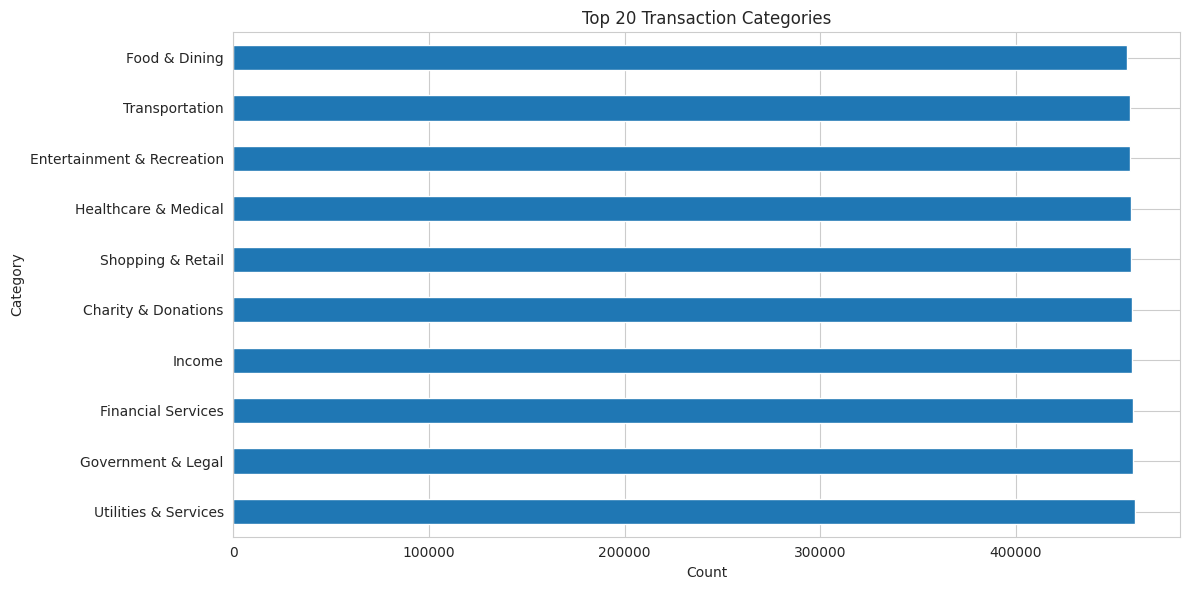


Most common:  Utilities & Services (460,842)
Least common: Food & Dining (456,928)
Imbalance ratio: 1.0x


In [5]:
print('Dataset Info:')
print(df.info())

print('\nMissing Values:')
print(df.isnull().sum())

print('\nNumber of unique categories:', df['category'].nunique())

category_counts = df['category'].value_counts()
print('\nCategory Distribution:')
print(category_counts)

plt.figure(figsize=(12, 6))
category_counts.head(20).plot(kind='barh')
plt.title('Top 20 Transaction Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print(f'\nMost common:  {category_counts.index[0]} ({category_counts.iloc[0]:,})')
print(f'Least common: {category_counts.index[-1]} ({category_counts.iloc[-1]:,})')
print(f'Imbalance ratio: {category_counts.iloc[0] / category_counts.iloc[-1]:.1f}x')

Data Preparation
Kept columns: ['transaction_description', 'category']
Total rows:   4,591,043

Duplicates removed: 3,201,504
Rows after dedup:   1,389,539


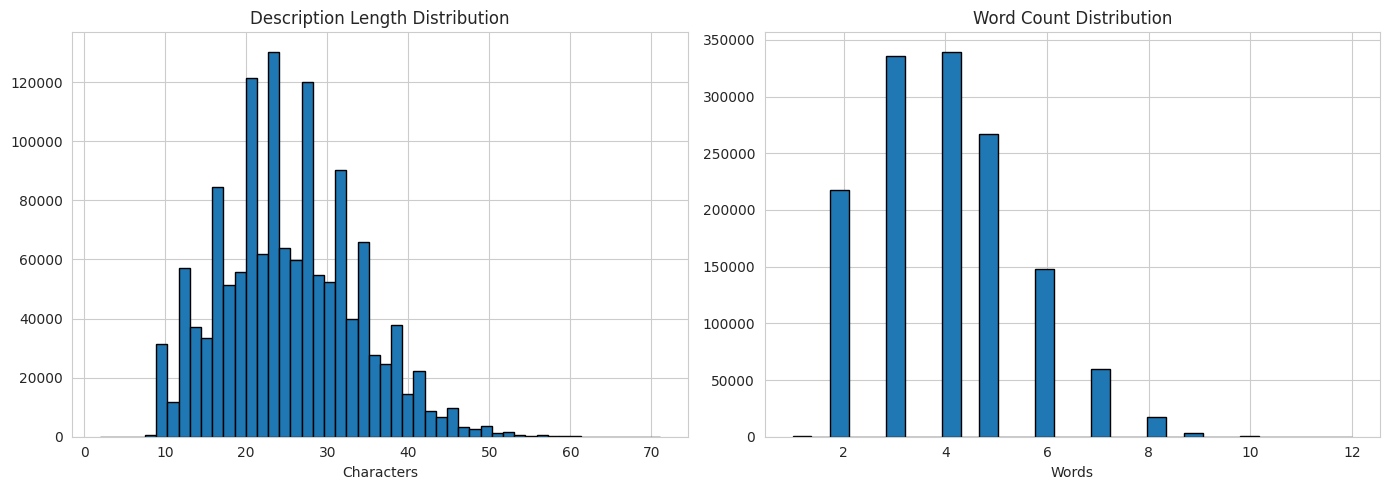

In [6]:
print('Data Preparation')
print('=' * 70)

df_model = df[['transaction_description', 'category']].copy()
print(f'Kept columns: {list(df_model.columns)}')
print(f'Total rows:   {len(df_model):,}')

# Remove exact duplicates
before = len(df_model)
df_model = df_model.drop_duplicates()
print(f'\nDuplicates removed: {before - len(df_model):,}')
print(f'Rows after dedup:   {len(df_model):,}')

# Description length stats
df_model['desc_length'] = df_model['transaction_description'].str.len()
df_model['word_count']  = df_model['transaction_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_model['desc_length'], bins=50, edgecolor='black')
axes[0].set_title('Description Length Distribution')
axes[0].set_xlabel('Characters')
axes[1].hist(df_model['word_count'], bins=30, edgecolor='black')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words')
plt.tight_layout()
plt.show()

In [7]:
def clean_transaction_description(text):
    """
    Clean transaction description for ML.
    FIXED: No longer removes useful signal words like 'online',
    'store', 'branch', 'station'. Only strips IDs and noise.
    """
    if pd.isna(text):
        return ''

    text = str(text).lower()

    # Remove country suffixes
    text = re.sub(r'\s*-\s*(australia|canada|india|uk|usa|nepal)\s*', ' ', text)

    # Remove transaction IDs and reference numbers
    text = re.sub(r'txn\d+', '', text)
    text = re.sub(r'#\d+', '', text)
    text = re.sub(r'\b\d{5,}\b', '', text)   # long standalone numbers only

    # Remove truly uninformative tokens
    text = re.sub(r'\(contactless\)', '', text)

    # ✅ REMOVED: online, store, branch, station — they ARE useful signals
    # Old (wrong) lines that were here:
    #   text = re.sub(r'\bonline\b', '', text)
    #   text = re.sub(r'\bstore\b', '', text)
    #   text = re.sub(r'\bbranch\b', '', text)
    #   text = re.sub(r'\bstation\b', '', text)

    # Keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


print('Applying fixed cleaning...')
df_model['cleaned_description'] = df_model['transaction_description'].apply(
    clean_transaction_description
)

empty_count = (df_model['cleaned_description'].str.len() == 0).sum()
print(f'Empty after cleaning: {empty_count}')
if empty_count > 0:
    df_model = df_model[df_model['cleaned_description'].str.len() > 0].copy()
    print(f'Removed {empty_count} empty rows')

print(f'Final dataset: {len(df_model):,} rows')

# Verify critical Nepali keywords survive cleaning
print('\nVerifying Nepali keywords survive cleaning:')
checks = [
    'Worldlink internet bill payment',
    'NEA electricity bill',
    'CWN water bill payment',
    'Vianet broadband payment',
    'Ncell top up',
]
for t in checks:
    print(f'  "{t}" → "{clean_transaction_description(t)}"')

Applying fixed cleaning...
Empty after cleaning: 11
Removed 11 empty rows
Final dataset: 1,389,528 rows

Verifying Nepali keywords survive cleaning:
  "Worldlink internet bill payment" → "worldlink internet bill payment"
  "NEA electricity bill" → "nea electricity bill"
  "CWN water bill payment" → "cwn water bill payment"
  "Vianet broadband payment" → "vianet broadband payment"
  "Ncell top up" → "ncell top up"


In [8]:
X = df_model['cleaned_description']
y = df_model['category']

print(f'Total samples:        {len(X):,}')
print(f'Number of categories: {y.nunique()}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

# ── Step 1: Keywords to FORCE into vocabulary ─────────────────────────────
# These are guaranteed slots — they will always be in the vocabulary
# regardless of how rare they are in the overall corpus
FORCED_VOCAB = [
    # Nepali ISPs
    'worldlink', 'vianet', 'subisu', 'classic tech', 'net tv',
    # Electricity
    'nea', 'electricity bill', 'electricity payment', 'bijuli', 'electricity',
    # Water
    'cwn', 'water bill', 'water supply', 'khanepani',
    # Mobile
    'ncell', 'ntc', 'ntc recharge', 'ncell recharge',
    # Other utilities
    'dish home', 'simtv', 'cooking gas', 'gas cylinder',
    # Generic utility phrases
    'internet bill', 'wifi bill', 'broadband bill',
]

# ── Step 2: Fit main TF-IDF on full training data ─────────────────────────
print('\nFitting main TF-IDF on full training data...')
tfidf_main = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.85
)
tfidf_main.fit(X_train)
main_vocab = tfidf_main.vocabulary_   # word → index dict

# ── Step 3: Fit a small TF-IDF only on the forced keywords ────────────────
# This guarantees these tokens get proper IDF weights from the corpus
print('Fitting keyword-focused TF-IDF...')
tfidf_keywords = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_df=1.0,
    vocabulary=FORCED_VOCAB          # fixed vocabulary = these words only
)
tfidf_keywords.fit(X_train)

# ── Step 4: Merge vocabularies ────────────────────────────────────────────
# Start with forced vocab at the front (indices 0..N-1)
# Then fill remaining slots with top words from main TF-IDF
merged_vocab = {}

# First, assign indices to forced keywords
for i, word in enumerate(FORCED_VOCAB):
    merged_vocab[word] = i

# Then fill with main vocab words that aren't already included
next_idx = len(FORCED_VOCAB)
for word, _ in sorted(main_vocab.items(), key=lambda x: x[1]):
    if word not in merged_vocab:
        merged_vocab[word] = next_idx
        next_idx += 1
        if next_idx >= 10000:
            break

print(f'Merged vocabulary size: {len(merged_vocab):,}')
print(f'  Forced slots: {len(FORCED_VOCAB)}')
print(f'  Main vocab slots: {len(merged_vocab) - len(FORCED_VOCAB):,}')

# ── Step 5: Refit TF-IDF with the merged vocabulary ───────────────────────
print('\nRefitting TF-IDF with merged vocabulary...')
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.85,
    vocabulary=merged_vocab          # fixed — no more dropping rare words
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Train features: {X_train_tfidf.shape}')
print(f'Test features:  {X_test_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')

# ── Step 6: Verify ────────────────────────────────────────────────────────
print('\nCritical keyword vocabulary check:')
keywords_to_check = [
    'worldlink', 'vianet', 'subisu', 'ncell', 'nea',
    'electricity', 'cwn', 'broadband', 'internet', 'ntc',
    'water bill', 'electricity bill', 'internet bill',
]
all_present = True
for kw in keywords_to_check:
    status = '✓ IN vocab' if kw in tfidf.vocabulary_ else '✗ MISSING'
    if '✗' in status:
        all_present = False
    print(f'  {kw:<25} {status}')

print(f'\n{"✓ All critical keywords present!" if all_present else "✗ Some keywords still missing — add them to FORCED_VOCAB above"}'  )

Total samples:        1,389,528
Number of categories: 10

Train: 1,111,622 | Test: 277,906

Fitting main TF-IDF on full training data...
Fitting keyword-focused TF-IDF...
Merged vocabulary size: 10,000
  Forced slots: 25
  Main vocab slots: 9,975

Refitting TF-IDF with merged vocabulary...
Train features: (1111622, 10000)
Test features:  (277906, 10000)
Vocabulary size: 10,000

Critical keyword vocabulary check:
  worldlink                 ✓ IN vocab
  vianet                    ✓ IN vocab
  subisu                    ✓ IN vocab
  ncell                     ✓ IN vocab
  nea                       ✓ IN vocab
  electricity               ✓ IN vocab
  cwn                       ✓ IN vocab
  broadband                 ✓ IN vocab
  internet                  ✓ IN vocab
  ntc                       ✓ IN vocab
  water bill                ✓ IN vocab
  electricity bill          ✓ IN vocab
  internet bill             ✓ IN vocab

✓ All critical keywords present!


In [9]:
print('Training Model 1: Logistic Regression')
print('=' * 70)

# FIX: class_weight='balanced' compensates for category imbalance
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'   # was missing — fixes minority category bias
)

start = time.time()
lr_model.fit(X_train_tfidf, y_train)
print(f'✓ Trained in {time.time()-start:.2f}s')

y_pred_lr = lr_model.predict(X_test_tfidf)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f'\nAccuracy: {accuracy_lr*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

Training Model 1: Logistic Regression
✓ Trained in 46.58s

Accuracy: 98.27%

Classification Report:
                            precision    recall  f1-score   support

       Charity & Donations       1.00      1.00      1.00     27475
Entertainment & Recreation       0.99      0.98      0.99     27965
        Financial Services       1.00      1.00      1.00     27852
             Food & Dining       0.99      0.99      0.99     28019
        Government & Legal       0.98      0.97      0.98     27842
      Healthcare & Medical       0.97      0.96      0.97     27768
                    Income       0.98      1.00      0.99     27273
         Shopping & Retail       0.93      0.94      0.94     28050
            Transportation       0.99      0.98      0.99     28033
      Utilities & Services       0.98      0.99      0.99     27629

                  accuracy                           0.98    277906
                 macro avg       0.98      0.98      0.98    277906
              

In [10]:
print('Training Model 2: Naive Bayes')
print('=' * 70)

nb_model = MultinomialNB()

start = time.time()
nb_model.fit(X_train_tfidf, y_train)
print(f'✓ Trained in {time.time()-start:.2f}s')

y_pred_nb = nb_model.predict(X_test_tfidf)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f'\nAccuracy: {accuracy_nb*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb))

Training Model 2: Naive Bayes
✓ Trained in 3.69s

Accuracy: 98.05%

Classification Report:
                            precision    recall  f1-score   support

       Charity & Donations       1.00      1.00      1.00     27475
Entertainment & Recreation       1.00      0.98      0.99     27965
        Financial Services       0.99      1.00      1.00     27852
             Food & Dining       1.00      0.98      0.99     28019
        Government & Legal       1.00      0.96      0.98     27842
      Healthcare & Medical       0.99      0.94      0.97     27768
                    Income       0.98      1.00      0.99     27273
         Shopping & Retail       0.89      0.98      0.93     28050
            Transportation       0.98      0.98      0.98     28033
      Utilities & Services       0.99      0.99      0.99     27629

                  accuracy                           0.98    277906
                 macro avg       0.98      0.98      0.98    277906
              weighted 

In [11]:
!pip install xgboost -q
import xgboost as xgb

print('Training Model 3: XGBoost')
print('=' * 70)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    verbosity=1
)

start = time.time()
xgb_model.fit(X_train_tfidf, y_train_enc)
train_time = time.time()-start
print(f'✓ Trained in {train_time:.2f}s ({train_time/60:.1f} min)')

y_pred_xgb_enc = xgb_model.predict(X_test_tfidf)
y_pred_xgb     = label_encoder.inverse_transform(y_pred_xgb_enc)
accuracy_xgb   = accuracy_score(y_test, y_pred_xgb)

print(f'\nAccuracy: {accuracy_xgb*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

Training Model 3: XGBoost
✓ Trained in 255.96s (4.3 min)

Accuracy: 98.07%

Classification Report:
                            precision    recall  f1-score   support

       Charity & Donations       1.00      1.00      1.00     27475
Entertainment & Recreation       1.00      0.98      0.99     27965
        Financial Services       1.00      1.00      1.00     27852
             Food & Dining       0.96      0.98      0.97     28019
        Government & Legal       1.00      0.95      0.98     27842
      Healthcare & Medical       0.96      0.98      0.97     27768
                    Income       0.98      1.00      0.99     27273
         Shopping & Retail       0.93      0.94      0.94     28050
            Transportation       1.00      0.97      0.99     28033
      Utilities & Services       0.98      1.00      0.99     27629

                  accuracy                           0.98    277906
                 macro avg       0.98      0.98      0.98    277906
              w

In [12]:
print('Training Model 4: SGD Classifier')
print('=' * 70)

sgd_model = SGDClassifier(
    loss='log_loss',
    max_iter=100,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'   # FIX: added
)

start = time.time()
sgd_model.fit(X_train_tfidf, y_train)
print(f'✓ Trained in {time.time()-start:.2f}s')

y_pred_sgd = sgd_model.predict(X_test_tfidf)
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)

print(f'\nAccuracy: {accuracy_sgd*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_sgd))

Training Model 4: SGD Classifier
✓ Trained in 19.29s

Accuracy: 98.13%

Classification Report:
                            precision    recall  f1-score   support

       Charity & Donations       1.00      1.00      1.00     27475
Entertainment & Recreation       1.00      0.98      0.99     27965
        Financial Services       1.00      1.00      1.00     27852
             Food & Dining       1.00      0.98      0.99     28019
        Government & Legal       1.00      0.96      0.98     27842
      Healthcare & Medical       0.97      0.97      0.97     27768
                    Income       0.98      1.00      0.99     27273
         Shopping & Retail       0.93      0.95      0.94     28050
            Transportation       0.97      0.98      0.97     28033
      Utilities & Services       0.98      1.00      0.99     27629

                  accuracy                           0.98    277906
                 macro avg       0.98      0.98      0.98    277906
              weigh

In [13]:
print('Training Model 5: Random Forest')
print('=' * 70)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # FIX: added
)

start = time.time()
rf_model.fit(X_train_tfidf, y_train)
train_time = time.time()-start
print(f'✓ Trained in {train_time:.2f}s ({train_time/60:.1f} min)')

y_pred_rf = rf_model.predict(X_test_tfidf)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f'\nAccuracy: {accuracy_rf*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

Training Model 5: Random Forest
✓ Trained in 975.28s (16.3 min)

Accuracy: 98.27%

Classification Report:
                            precision    recall  f1-score   support

       Charity & Donations       1.00      1.00      1.00     27475
Entertainment & Recreation       0.99      0.99      0.99     27965
        Financial Services       1.00      1.00      1.00     27852
             Food & Dining       0.99      0.98      0.99     28019
        Government & Legal       0.98      0.98      0.98     27842
      Healthcare & Medical       0.96      0.98      0.97     27768
                    Income       0.98      0.99      0.99     27273
         Shopping & Retail       0.95      0.92      0.94     28050
            Transportation       0.99      0.98      0.99     28033
      Utilities & Services       0.98      0.99      0.99     27629

                  accuracy                           0.98    277906
                 macro avg       0.98      0.98      0.98    277906
        

In [14]:
results = {
    'Logistic Regression': accuracy_lr,
    'Naive Bayes':         accuracy_nb,
    'Random Forest':       accuracy_rf,
    'XGBoost':             accuracy_xgb,
    'SGD Classifier':      accuracy_sgd,
}

print('Model Accuracy Comparison')
print('=' * 40)
for model, acc in sorted(results.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 40)
    print(f'{model:<22} {acc*100:6.2f}%  {bar}')

best_model_name = max(results, key=results.get)
print(f'\nBest model: {best_model_name} ({results[best_model_name]*100:.2f}%)')

Model Accuracy Comparison
Logistic Regression     98.27%  ███████████████████████████████████████
Random Forest           98.27%  ███████████████████████████████████████
SGD Classifier          98.13%  ███████████████████████████████████████
XGBoost                 98.07%  ███████████████████████████████████████
Naive Bayes             98.05%  ███████████████████████████████████████

Best model: Logistic Regression (98.27%)


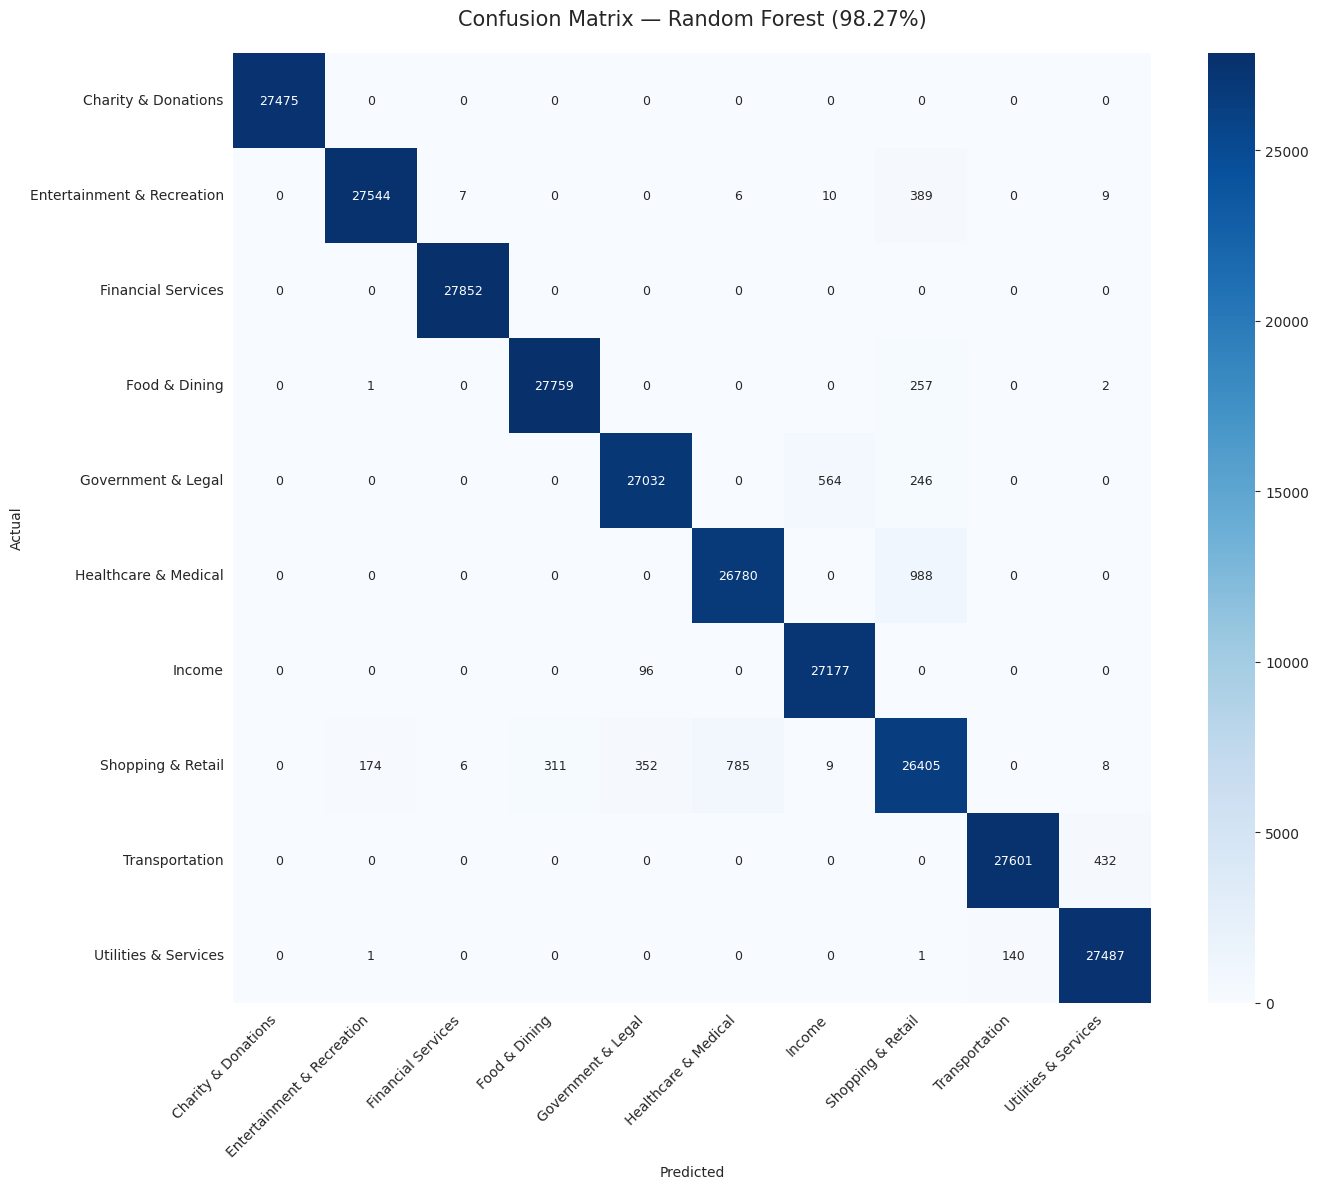


Per-Category Accuracy:
Charity & Donations                 27475/27475 = 100.00%
Entertainment & Recreation          27544/27965 =  98.49%
Financial Services                  27852/27852 = 100.00%
Food & Dining                       27759/28019 =  99.07%
Government & Legal                  27032/27842 =  97.09%
Healthcare & Medical                26780/27768 =  96.44%
Income                              27177/27273 =  99.65%
Shopping & Retail                   26405/28050 =  94.14%
Transportation                      27601/28033 =  98.46%
Utilities & Services                27487/27629 =  99.49%


In [15]:
# Use Logistic regression as final model
final_model       = lr_model
final_predictions = y_pred_lr
final_accuracy    = accuracy_lr

categories = sorted(y_test.unique())
cm    = confusion_matrix(y_test, final_predictions, labels=categories)
cm_df = pd.DataFrame(cm, index=categories, columns=categories)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            annot_kws={'size': 9})
plt.title(f'Confusion Matrix — Random Forest ({final_accuracy*100:.2f}%)',
          fontsize=15, pad=20)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nPer-Category Accuracy:')
print('=' * 50)
for i, cat in enumerate(categories):
    correct = cm[i][i]
    total   = cm[i].sum()
    acc     = correct / total * 100 if total > 0 else 0
    print(f'{cat:<35} {correct:>5}/{total:<5} = {acc:>6.2f}%')

In [16]:
# Keyword rules — checked BEFORE the ML model
# Add any new Nepali brands/services here
KEYWORD_RULES = {
    'Utilities & Bills': [
        # Internet / ISPs
        'worldlink', 'vianet', 'subisu', 'ntc broadband', 'classic tech',
        'net tv', 'dish home', 'simtv', 'sky tv',
        # Electricity
        'nea', 'nepal electricity', 'electricity bill', 'electricity payment',
        'power bill', 'bijuli', 'bijulee',
        # Water
        'cwn', 'water bill', 'water supply', 'water payment',
        'kathmandu upatyaka', 'drinking water',
        # Mobile / Telecom
        'ncell', 'ntc recharge', 'mobile recharge', 'ntc postpaid',
        'ncell recharge', 'ntc prepaid',
        # Gas
        'cooking gas', 'gas cylinder', 'gas bill',
        # Generic
        'internet bill', 'wifi bill', 'broadband bill', 'utility bill',
    ],
    'Income': [
        'salary credit', 'payroll deposit', 'stipend', 'freelance payment',
        'salary deposit', 'wage credit', 'bonus credit',
    ],
    'Healthcare & Medical': [
        'bir hospital', 'patan hospital', 'norvic', 'om hospital',
        'teaching hospital', 'medicare', 'pharmacy payment',
    ],
    'Education': [
        'school fee', 'college fee', 'tuition fee', 'examination fee',
        'university fee', 'ioe fee', 'pu fee', 'tu fee',
    ],
}


def predict_category(description, model, vectorizer):
    """
    Hybrid predictor: keyword rules first, ML model as fallback.
    Returns (category, confidence, method_used)
    """
    desc_lower = str(description).lower()

    # Step 1: Check keyword rules
    for category, keywords in KEYWORD_RULES.items():
        if any(kw in desc_lower for kw in keywords):
            return category, 1.0, 'rule'

    # Step 2: Fall back to ML model
    cleaned    = clean_transaction_description(description)
    features   = vectorizer.transform([cleaned])
    prediction = model.predict(features)[0]
    proba      = model.predict_proba(features)[0]
    confidence = max(proba)

    return prediction, confidence, 'ml'


print('Hybrid predictor defined.')
print('predict_category(description, model, vectorizer) → (category, confidence, method)')

Hybrid predictor defined.
predict_category(description, model, vectorizer) → (category, confidence, method)


In [17]:
test_transactions = [
    # --- Previously failing (Nepali utilities) ---
    ('Worldlink Payment',              'Utilities & Bills'),
    ('Worldlink internet bill',        'Utilities & Bills'),
    ('Worldlink monthly payment',      'Utilities & Bills'),
    ('NEA electricity bill',           'Utilities & Bills'),
    ('Nepal Electricity Authority',    'Utilities & Bills'),
    ('CWN water bill payment',         'Utilities & Bills'),
    ('Kathmandu water supply',         'Utilities & Bills'),
    ('Vianet broadband payment',       'Utilities & Bills'),
    ('Subisu cable internet',          'Utilities & Bills'),
    ('Ncell top up',                   'Utilities & Bills'),
    ('NTC mobile recharge',            'Utilities & Bills'),
    ('Dish home subscription',         'Utilities & Bills'),
    # --- Should still work (English transactions) ---
    ('Starbucks coffee',               'Food & Dining'),
    ('McDonald\'s burger',            'Food & Dining'),
    ('walmart grocery shopping',       'Shopping & Retail'),
    ('Amazon online purchase',         'Shopping & Retail'),
    ('Uber ride to airport',           'Transportation'),
    ('Shell gas station',              'Transportation'),
    ('Netflix subscription',           'Entertainment & Recreation'),
    ('salary deposit',                 'Income'),
    ('CVS pharmacy prescription',      'Healthcare & Medical'),
    ('property tax payment',           'Government & Legal'),
    ('Red Cross donation',             'Charity & Donations'),
]

print(f'{"Transaction":<40} {"Expected":<25} {"Predicted":<25} {"Conf":>6}  {"Method"}')
print('-' * 115)

correct = 0
for desc, expected in test_transactions:
    cat, conf, method = predict_category(desc, lr_model, tfidf)
    tick = '✓' if cat == expected else '✗'
    if cat == expected:
        correct += 1
    print(f'{tick} {desc:<38} {expected:<25} {cat:<25} {conf*100:5.0f}%  [{method}]')

print('-' * 115)
print(f'\nResult: {correct}/{len(test_transactions)} correct ({correct/len(test_transactions)*100:.0f}%)')

Transaction                              Expected                  Predicted                   Conf  Method
-------------------------------------------------------------------------------------------------------------------
✓ Worldlink Payment                      Utilities & Bills         Utilities & Bills           100%  [rule]
✓ Worldlink internet bill                Utilities & Bills         Utilities & Bills           100%  [rule]
✓ Worldlink monthly payment              Utilities & Bills         Utilities & Bills           100%  [rule]
✓ NEA electricity bill                   Utilities & Bills         Utilities & Bills           100%  [rule]
✓ Nepal Electricity Authority            Utilities & Bills         Utilities & Bills           100%  [rule]
✓ CWN water bill payment                 Utilities & Bills         Utilities & Bills           100%  [rule]
✓ Kathmandu water supply                 Utilities & Bills         Utilities & Bills           100%  [rule]
✓ Vianet broadband p

In [18]:
save_path = '/content/drive/MyDrive/SeventhSemMl/'

with open(save_path + 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open(save_path + 'lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open(save_path + 'rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open(save_path + 'keyword_rules.pkl', 'wb') as f:
    pickle.dump(KEYWORD_RULES, f)

print('✓ Saved:')
print('  tfidf_vectorizer.pkl')
print('  lr_model.pkl')
print('  rf_model.pkl')
print('  keyword_rules.pkl')

✓ Saved:
  tfidf_vectorizer.pkl
  lr_model.pkl
  rf_model.pkl
  keyword_rules.pkl


In [22]:
save_path = '/content/drive/MyDrive/SeventhSemMl/'

with open(save_path + 'tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_loaded = pickle.load(f)

with open(save_path + 'lr_model.pkl', 'rb') as f:
    lr_loaded = pickle.load(f)

with open(save_path + 'keyword_rules.pkl', 'rb') as f:
    KEYWORD_RULES_loaded = pickle.load(f)

print('✓ Models loaded successfully')

# Quick test with loaded models
test_desc = 'Starbucks '
cat, conf, method = predict_category(test_desc, lr_loaded, tfidf_loaded)
print(f'\nTest: "{test_desc}" → {cat} ({conf*100:.0f}%, {method})')

✓ Models loaded successfully

Test: "Starbucks " → Food & Dining (100%, ml)
